In [ ]:
import os
import cv2
import h5py
import yaml
import shutil
import random
import tarfile
import requests
import numpy as np
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from ultralytics import YOLO
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
root = Path('/kaggle/working/lab5_svhn')
raw_dir = root / 'raw'
yolo_dir = root / 'yolo'
runs_dir = root / 'runs'

for p in [raw_dir, yolo_dir, runs_dir]:
    p.mkdir(parents=True, exist_ok=True)

urls = {
    'train': 'http://ufldl.stanford.edu/housenumbers/train.tar.gz',
    'test':  'http://ufldl.stanford.edu/housenumbers/test.tar.gz',
}

seed = 42
random.seed(seed)
np.random.seed(seed)

imgsz = 640
epochs = 15
batch_size = 32
device = 'cuda'


In [ ]:

def download_file(url: str, dst: Path):
    if dst.exists():
        print(f'Уже скачан: {dst}')
        return
    print(f'Скачивание: {url}')
    with requests.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        with open(dst, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True, desc=dst.name) as pbar:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

for split, url in urls.items():
    download_file(url, raw_dir / f'{split}.tar.gz')

Скачивание: http://ufldl.stanford.edu/housenumbers/train.tar.gz


train.tar.gz: 100%|██████████| 404M/404M [00:09<00:00, 43.2MB/s] 


Скачивание: http://ufldl.stanford.edu/housenumbers/test.tar.gz


test.tar.gz: 100%|██████████| 277M/277M [00:06<00:00, 40.2MB/s] 


In [ ]:
def extract_tar_gz(archive_path: Path, target_dir: Path):
    split_name = archive_path.stem.replace('.tar', '')
    out_dir = target_dir / split_name
    if out_dir.exists() and any(out_dir.iterdir()):
        return out_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f'Распаковка: {archive_path.name}')
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(path=target_dir, filter='data')
    return out_dir

train_raw = extract_tar_gz(raw_dir / 'train.tar.gz', raw_dir)
test_raw = extract_tar_gz(raw_dir / 'test.tar.gz', raw_dir)

print('train_raw:', train_raw)
print('test_raw:', test_raw)

Распаковка: train.tar.gz
Распаковка: test.tar.gz
train_raw: /kaggle/working/lab5_svhn/raw/train
test_raw: /kaggle/working/lab5_svhn/raw/test


In [ ]:
def read_name(mat_file, name_ref):
    name_arr = mat_file[name_ref][()]
    return ''.join(chr(c[0]) for c in name_arr)


def read_numeric_list(mat_file, ds):
    vals = []
    for i in range(ds.shape[0]):
        item = ds[i][0]
        if isinstance(item, h5py.Reference):
            v = mat_file[item][()]
            v = float(np.array(v).squeeze())
        else:
            v = float(np.array(item).squeeze())
        vals.append(v)
    return vals


def parse_digit_struct(mat_path: Path):
    data = {}
    with h5py.File(mat_path, 'r') as f:
        digit_struct = f['digitStruct']
        names_ds = digit_struct['name']
        bbox_ds = digit_struct['bbox']

        n = names_ds.shape[0]
        for i in tqdm(range(n), desc=f'Парсинг {mat_path.parent.name}'):
            name_ref = names_ds[i][0]
            bbox_ref = bbox_ds[i][0]

            img_name = read_name(f, name_ref)
            bbox = f[bbox_ref]

            labels = read_numeric_list(f, bbox['label'])
            lefts = read_numeric_list(f, bbox['left'])
            tops = read_numeric_list(f, bbox['top'])
            widths = read_numeric_list(f, bbox['width'])
            heights = read_numeric_list(f, bbox['height'])

            boxes = []
            for lab, l, t, w, h in zip(labels, lefts, tops, widths, heights):
                cls = int(lab)
                if cls == 10:
                    cls = 0
                boxes.append({
                    'cls': cls,
                    'left': float(l),
                    'top': float(t),
                    'width': float(w),
                    'height': float(h)
                })
            data[img_name] = boxes
    return data


train_ann = parse_digit_struct(train_raw / 'digitStruct.mat')
test_ann = parse_digit_struct(test_raw / 'digitStruct.mat')

print('train images:', len(train_ann))
print('test images:', len(test_ann))

Парсинг test: 100%|██████████| 13068/13068 [00:50<00:00, 259.04it/s]


train images: 33402
test images: 13068


In [ ]:
for split in ['train', 'val', 'test']:
    (yolo_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
    (yolo_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

train_names = sorted(list(train_ann.keys()))
train_names, val_names = train_test_split(train_names, test_size=0.1, random_state=seed, shuffle=True)
test_names = sorted(list(test_ann.keys()))

print('train:', len(train_names), 'val:', len(val_names), 'test:', len(test_names))

train: 30061 val: 3341 test: 13068


In [ ]:
def clip_box_xyxy(x1, y1, x2, y2, w, h):
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w - 1))
    y2 = max(0, min(y2, h - 1))
    return x1, y1, x2, y2


def to_yolo_line(cls, x1, y1, x2, y2, w, h):
    bw = max(1e-6, x2 - x1)
    bh = max(1e-6, y2 - y1)
    xc = x1 + bw / 2.0
    yc = y1 + bh / 2.0
    return f"{cls} {xc / w:.6f} {yc / h:.6f} {bw / w:.6f} {bh / h:.6f}"


def write_split(split_name, names, ann_dict, src_img_dir):
    img_out = yolo_dir / 'images' / split_name
    lbl_out = yolo_dir / 'labels' / split_name

    for name in tqdm(names, desc=f'Готовим {split_name}'):
        src_img = src_img_dir / name
        dst_img = img_out / name
        shutil.copy2(src_img, dst_img)

        img = cv2.imread(str(dst_img))
        h, w = img.shape[:2]

        lines = []
        for b in ann_dict[name]:
            x1 = b['left']
            y1 = b['top']
            x2 = b['left'] + b['width']
            y2 = b['top'] + b['height']
            x1, y1, x2, y2 = clip_box_xyxy(x1, y1, x2, y2, w, h)
            if x2 <= x1 or y2 <= y1:
                continue
            lines.append(to_yolo_line(b['cls'], x1, y1, x2, y2, w, h))

        label_path = lbl_out / f"{Path(name).stem}.txt"
        with open(label_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))


write_split('train', train_names, train_ann, train_raw)
write_split('val', val_names, train_ann, train_raw)
write_split('test', test_names, test_ann, test_raw)

Готовим test: 100%|██████████| 13068/13068 [00:13<00:00, 936.91it/s] 


In [ ]:
data_yaml = yolo_dir / 'svhn.yaml'
yaml_data = {
    'path': str(yolo_dir),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: str(i) for i in range(10)}
}
with open(data_yaml, 'w', encoding='utf-8') as f:
    yaml.safe_dump(yaml_data, f, sort_keys=False, allow_unicode=True)

print('data yaml:', data_yaml)
print(data_yaml.read_text()[:300])

data yaml: /kaggle/working/lab5_svhn/yolo/svhn.yaml
path: /kaggle/working/lab5_svhn/yolo
train: images/train
val: images/val
test: images/test
names:
  0: '0'
  1: '1'
  2: '2'
  3: '3'
  4: '4'
  5: '5'
  6: '6'
  7: '7'
  8: '8'
  9: '9'



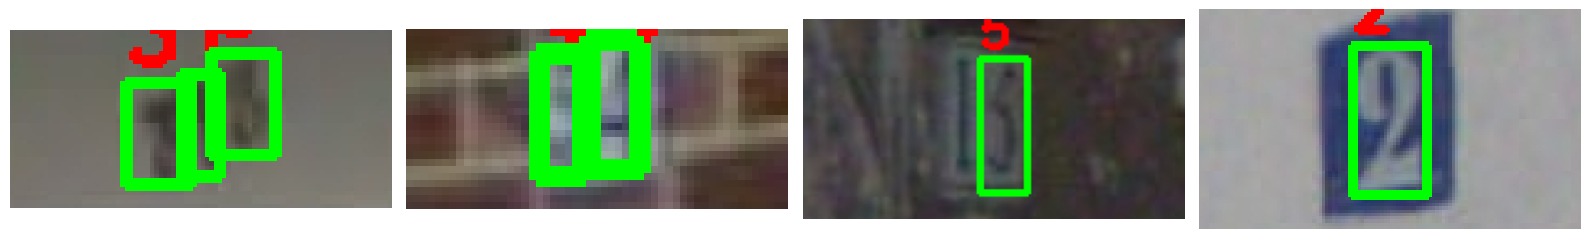

In [ ]:
def draw_yolo_labels(img_path, lbl_path, max_boxes=30):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if lbl_path.exists():
        with open(lbl_path, 'r', encoding='utf-8') as f:
            lines = [x.strip() for x in f if x.strip()]
        for line in lines[:max_boxes]:
            cls, xc, yc, bw, bh = line.split()
            cls = int(cls)
            xc, yc, bw, bh = map(float, [xc, yc, bw, bh])
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, str(cls), (x1, max(0, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return img

sample_imgs = list((yolo_dir / 'images' / 'train').glob('*.png'))[:4]
plt.figure(figsize=(16, 4))
for i, p in enumerate(sample_imgs, 1):
    lbl = yolo_dir / 'labels' / 'train' / f'{p.stem}.txt'
    vis = draw_yolo_labels(p, lbl)
    plt.subplot(1, 4, i)
    plt.imshow(vis)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
print(f'Старт обучения: epochs={epochs}, imgsz={imgsz}, batch={batch_size}')
model = YOLO('yolov8n.pt')

train_results = model.train(
    data=str(data_yaml),
    epochs=epochs,
    imgsz=imgsz,
    batch=batch_size,
    device=device,
    workers=2,
    optimizer='AdamW',
    lr0=1e-3,
    weight_decay=5e-4,
    patience=10,
    project=str(runs_dir),
    name='svhn_yolov8n',
    verbose=True,
    plots=True
)


Старт обучения: epochs=15, imgsz=640, batch=32
Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/lab5_svhn/yolo/svhn.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=svhn_yolov8n, nbs=64, nms=False, opset=None, optimize=Fals

In [ ]:
best_path = runs_dir / 'svhn_yolov8n' / 'weights' / 'best.pt'
best_model = YOLO(str(best_path))

metrics = best_model.val(
    data=str(data_yaml),
    split='test',
    imgsz=imgsz,
    device=device,
    verbose=True
)

precision = float(metrics.box.mp)
recall = float(metrics.box.mr)
map50 = float(metrics.box.map50)
map5095 = float(metrics.box.map)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'mAP@0.5:   {map50:.4f}')
print(f'mAP@0.5:0.95: {map5095:.4f}')

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 887.4±729.8 MB/s, size: 40.6 KB)
val: Scanning /kaggle/working/lab5_svhn/yolo/labels/test... 13068 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13068/13068 1.2Kit/s 10.5s<0.0s
val: New cache created: /kaggle/working/lab5_svhn/yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 817/817 12.3it/s 1:060.1sss
                   all      13068      26032      0.896      0.863        0.9      0.431
                     0       1687       1744      0.887      0.908      0.918      0.451
                     1       4578       5099      0.887      0.785      0.853      0.355
                     2       3834       4149      0.912      0.885      0.915      0.446
                     3       2696      

In [ ]:
def yolo_to_xyxy(lbl_arr, w, h):
    out = []
    for row in lbl_arr:
        cls, xc, yc, bw, bh = row
        x1 = (xc - bw/2) * w
        y1 = (yc - bh/2) * h
        x2 = (xc + bw/2) * w
        y2 = (yc + bh/2) * h
        out.append([int(cls), x1, y1, x2, y2])
    return out


def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    iw = max(0.0, inter_x2 - inter_x1)
    ih = max(0.0, inter_y2 - inter_y1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter + 1e-9
    return inter / union


def mean_iou_on_test(model, test_images_dir, test_labels_dir, max_images=3000, conf=0.25):
    img_paths = sorted(list(Path(test_images_dir).glob('*.png')))
    if max_images is not None:
        img_paths = img_paths[:max_images]

    ious = []
    for img_path in tqdm(img_paths, desc='IoU test'):
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]

        lbl_path = Path(test_labels_dir) / f'{img_path.stem}.txt'
        if not lbl_path.exists():
            continue

        gt_rows = []
        with open(lbl_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    gt_rows.append(list(map(float, line.strip().split())))
        if len(gt_rows) == 0:
            continue

        gt = yolo_to_xyxy(np.array(gt_rows, dtype=np.float32), w, h)

        res = model.predict(source=str(img_path), conf=conf, iou=0.5, imgsz=imgsz, verbose=False)[0]
        if res.boxes is None or len(res.boxes) == 0:
            continue

        pred_cls = res.boxes.cls.cpu().numpy().astype(int)
        pred_xyxy = res.boxes.xyxy.cpu().numpy()

        used_gt = set()
        for pc, pb in zip(pred_cls, pred_xyxy):
            best_iou = 0.0
            best_j = -1
            for j, g in enumerate(gt):
                if j in used_gt:
                    continue
                gc, gx1, gy1, gx2, gy2 = g
                if int(gc) != int(pc):
                    continue
                iou = iou_xyxy(pb, [gx1, gy1, gx2, gy2])
                if iou > best_iou:
                    best_iou = iou
                    best_j = j
            if best_j >= 0:
                used_gt.add(best_j)
                ious.append(best_iou)

    return float(np.mean(ious)) if len(ious) else 0.0


mean_iou = mean_iou_on_test(
    best_model,
    yolo_dir / 'images' / 'test',
    yolo_dir / 'labels' / 'test',
    max_images=3000,
    conf=0.25
)
print(f'Mean IoU (matched boxes): {mean_iou:.4f}')

IoU test: 100%|██████████| 3000/3000 [00:31<00:00, 95.47it/s] 

Mean IoU (matched boxes): 0.7301


In [ ]:
import gdown
import zipfile
import shutil
from pathlib import Path

photos_dir = Path('/kaggle/working/lab5_photos')
photos_dir.mkdir(parents=True, exist_ok=True)

zip_path = photos_dir / 'myphotos.zip'

gdown.download(f'https://drive.google.com/uc?id=1xpWQejylEbAHX1rH01VwfR_D1bYEYHBH', str(zip_path), quiet=False)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(photos_dir)

mac_dir = photos_dir / '__MACOSX'
if mac_dir.exists():
    shutil.rmtree(mac_dir)

for p in photos_dir.rglob('._*'):
    if p.is_file():
        p.unlink()

all_photos = [
    p for p in photos_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in ['.heic']
]

print(len(all_photos))
for p in all_photos:
    print(p)


Downloading...
From: https://drive.google.com/uc?id=1xpWQejylEbAHX1rH01VwfR_D1bYEYHBH
To: /kaggle/working/lab5_photos/myphotos.zip
100%|██████████| 5.94M/5.94M [00:00<00:00, 45.9MB/s]

12
/kaggle/working/lab5_photos/cv_lab5/IMG_9445.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9447.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9446.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9443.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9436.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9439.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9444.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9449.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9448.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9437.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9442.heic
/kaggle/working/lab5_photos/cv_lab5/IMG_9441.heic


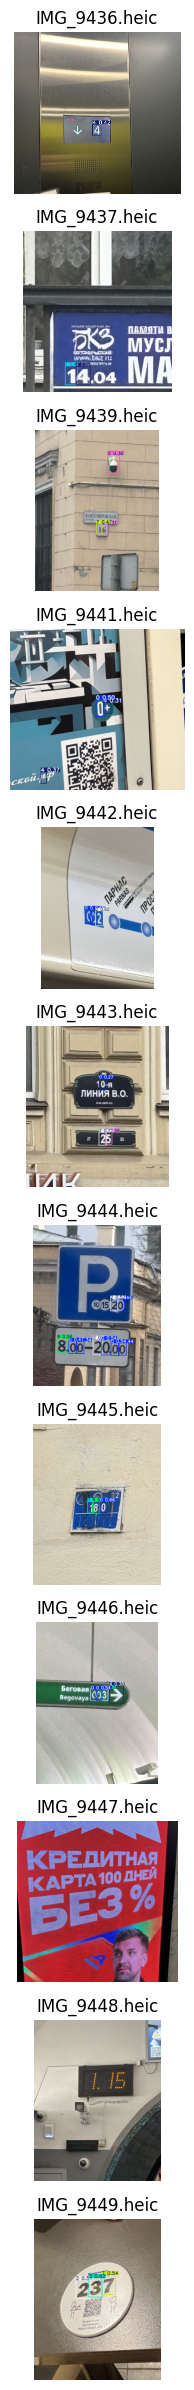

In [ ]:
photo_paths = [p for p in photos_dir.rglob('*') if p.suffix.lower() in ['.heic']]
photo_paths = sorted(photo_paths)

pred_results = best_model.predict(
    source=[str(p) for p in photo_paths],
    conf=0.25,
    iou=0.5,
    imgsz=imgsz,
    verbose=False
)

n = len(pred_results)
plt.figure(figsize=(16, 2 * n))
for i in range(n):
    img_bgr = pred_results[i].plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(n, 1, i + 1)
    plt.imshow(img_rgb)
    plt.title(photo_paths[i].name)
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
print(f'IoU (mean, matched): {mean_iou:.4f}')
print(f'Precision:           {precision:.4f}')
print(f'Recall:              {recall:.4f}')
print(f'mAP@0.5:             {map50:.4f}')
print(f'mAP@0.5:0.95:        {map5095:.4f}')

IoU (mean, matched): 0.7301
Precision:           0.8959
Recall:              0.8626
mAP@0.5:             0.8999
mAP@0.5:0.95:        0.4308
